## Statistical comparison of AWS Arctic retrievals and EarthCARE

This notebook plots 1D histograms and 2D conditional distributions of **collocated** AWS FWP (or LWP) and EarthCARE IWP (or LWP).
The actual statistics are computed using ``compute_aws_earthcare_coloc_stats.py``, which loads the collocations, averages over EarthCARE data, and calculates the histograms.

In [1]:
import numpy as np
import xarray as xr
import pickle
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt

plt.style.use("../plotstyling.mplstyle")

In [7]:
date_str = "2025-12_to_2026-02"
quantity = "lwp"   # or "lwp"

variable_label = quantity.upper()


with open(f"../data/aws_earthcare_histograms_{date_str}.pkl", "rb") as f:
    h_all = pickle.load(f)
h = h_all[quantity]

total_aws_counts = h["aws_counts"]
total_ea_counts = h["ea_counts"]
total_aws_n = h["aws_n"]
total_ea_n = h["ea_n"]

bins = h["bins"]
bin_widths = np.diff(bins)
bin_centres = np.sqrt(bins[:-1] * bins[1:])
bin_centres[0] = 5e-5   # stand-in for the 0 to 1e-4 bin

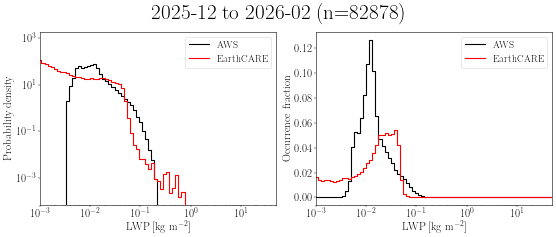

In [12]:
aws_hist_density = total_aws_counts / (total_aws_n * bin_widths)
ea_hist_density = total_ea_counts / (total_ea_n * bin_widths)

# occurrence fractions: counts / total, so each sums to 1 over all bins
aws_occ_frac = total_aws_counts / total_aws_n
ea_occ_frac = total_ea_counts / total_ea_n


fig, (ax_pdf, ax_of) = plt.subplots(1, 2, figsize=(14, 6))

# probability density
ax_pdf.step(bin_centres, aws_hist_density, where="mid", lw=2,
            color="black", label="AWS")
ax_pdf.step(bin_centres, ea_hist_density, where="mid", lw=2,
            color="red", label="EarthCARE")
ax_pdf.set_yscale("log")
ax_pdf.set_ylabel("Probability density")
#ax_pdf.set_ylim([1e-4, 5e2])

# occurrence fraction
ax_of.step(bin_centres, aws_occ_frac, where="mid", lw=2,
           color="black", label="AWS")
ax_of.step(bin_centres, ea_occ_frac, where="mid", lw=2,
           color="red", label="EarthCARE")
ax_of.set_ylabel("Occurrence fraction")
#ax_of.set_ylim([0, 0.1])

for ax in (ax_pdf, ax_of):
    ax.set_xscale("log")
    ax.set_xlim(1e-3, 5e1)
    ax.set_xlabel(rf"{variable_label} [kg m$^{{-2}}$]")
    ax.legend()

fig.suptitle(f"{date_str.replace('_', ' ')} (n={total_aws_n})")
fig.tight_layout()
plt.savefig(f"../figures/collocation_statistics/aws_earthcare_{quantity}_distributions_{date_str}.png",
            facecolor="white", bbox_inches="tight", dpi=200)

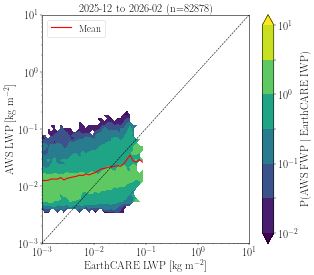

In [9]:
from matplotlib.colors import LogNorm


def conditional_probability_from_counts(counts_xy, bins_x, bins_y, log=False):
    """
    P(y|x) from 2D counts with rows = x bins, columns = y bins.

    Same result as normalising the joint density by the marginal p(x):
        p(x,y) = counts / (N * dx * dy)
        p(x)   = sum over y of p(x,y) * dy = counts_x / (N * dx)
        p(y|x) = p(x,y) / p(x) = counts / (counts_x * dy)

    log=True gives the density per log10 unit of y instead of per linear unit.
    Returns P(y|x) with rows = y, columns = x (ready for plotting), and counts_x.
    """
    if log:
        with np.errstate(divide="ignore"):
            dy = np.diff(np.log10(bins_y))
        dy[0] = dy[1]
    else:
        dy = np.diff(bins_y)

    counts_x = counts_xy.sum(axis=1)   # number of pairs in each x bin
    with np.errstate(invalid="ignore", divide="ignore"):
        y_given_x = counts_xy / (counts_x[:, None] * dy[None, :])

    return y_given_x.T, counts_x


# ------------------------------------------------------------
# data: joint_counts rows = EarthCARE (x), columns = AWS (y)
# ------------------------------------------------------------
counts = h["joint_counts"]
bins = h["bins"]
bin_centres = np.sqrt(bins[:-1] * bins[1:])
n_pairs = counts.sum()
min_count = 10

p_aws_given_ea, counts_ea = conditional_probability_from_counts(
    counts, bins, bins, log=True
)

# blank empty cells and EarthCARE bins with too few pairs
p_plot = np.where(p_aws_given_ea > 0, p_aws_given_ea, np.nan)
p_plot[:, counts_ea < min_count] = np.nan

# mean and median AWS FWP in each EarthCARE bin
joint = counts.T   # rows = AWS, columns = EarthCARE
with np.errstate(invalid="ignore", divide="ignore"):
    mean_aws = (joint * bin_centres[:, None]).sum(axis=0) / counts_ea
mean_aws[counts_ea < min_count] = np.nan

cum = np.cumsum(joint, axis=0)
median_aws = np.full(joint.shape[1], np.nan)
for j in range(joint.shape[1]):
    if counts_ea[j] >= min_count:
        median_aws[j] = bin_centres[np.searchsorted(cum[:, j], counts_ea[j] / 2)]

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
levels = np.logspace(-2, 1, 7)

fig, ax = plt.subplots(figsize=(8, 7))
cf = ax.contourf(bin_centres, bin_centres, p_plot,
                 levels=levels, norm=LogNorm(), cmap="viridis", extend="both")
fig.colorbar(cf, ax=ax, label="P(AWS FWP $|$ EarthCARE IWP)")


ax.plot(bin_centres, mean_aws, color="red", lw=2, label="Mean")
#ax.plot(bin_centres, median_aws, color="magenta", lw=2, label="Median AWS")
ax.plot([1e-3, 1e2], [1e-3, 1e2], color="black", ls="--", lw=1)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-3, 1e1)
ax.set_ylim(1e-3, 1e1)
ax.set_xlabel(rf"EarthCARE {variable_label} [kg m$^{{-2}}$]")
ax.set_ylabel(rf"AWS {variable_label} [kg m$^{{-2}}$]")
ax.set_title(f"{date_str.replace('_', ' ')} (n={total_aws_n})")
ax.legend(loc="upper left")
fig.tight_layout()
plt.savefig(f"../figures/collocation_statistics/aws_earthcare_{quantity}_conditional_{date_str}.png",
            facecolor="white", bbox_inches="tight", dpi=200)

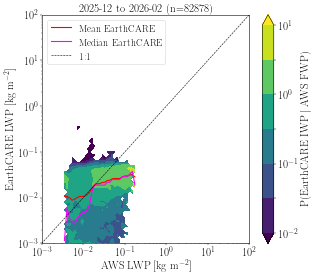

In [10]:
# ------------------------------------------------------------
# data: rows = AWS (x), columns = EarthCARE (y)
# ------------------------------------------------------------
counts_aws_x = h["joint_counts"].T
bins = h["bins"]
bin_centres = np.sqrt(bins[:-1] * bins[1:])
n_pairs = counts_aws_x.sum()
min_count = 10

p_ea_given_aws, counts_aws = conditional_probability_from_counts(
    counts_aws_x, bins, bins, log=True
)

# blank empty cells and AWS bins with too few pairs
p_plot = np.where(p_ea_given_aws > 0, p_ea_given_aws, np.nan)
p_plot[:, counts_aws < min_count] = np.nan

# mean and median EarthCARE IWP in each AWS bin
joint = h["joint_counts"]   # rows = EarthCARE, columns = AWS
with np.errstate(invalid="ignore", divide="ignore"):
    mean_ea = (joint * bin_centres[:, None]).sum(axis=0) / counts_aws
mean_ea[counts_aws < min_count] = np.nan

cum = np.cumsum(joint, axis=0)
median_ea = np.full(joint.shape[1], np.nan)
for j in range(joint.shape[1]):
    if counts_aws[j] >= min_count:
        median_ea[j] = bin_centres[np.searchsorted(cum[:, j], counts_aws[j] / 2)]

# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
levels = np.logspace(-2, 1, 7)

fig, ax = plt.subplots(figsize=(8, 7))
cf = ax.contourf(bin_centres, bin_centres, p_plot,
                 levels=levels, norm=LogNorm(), cmap="viridis", extend="both")
fig.colorbar(cf, ax=ax, label="P(EarthCARE IWP $|$ AWS FWP)")

ax.plot(bin_centres, mean_ea, color="red", lw=2, label="Mean EarthCARE")
ax.plot(bin_centres, median_ea, color="magenta", lw=2, label="Median EarthCARE")
ax.plot([1e-3, 1e2], [1e-3, 1e2], color="black", ls="--", lw=1, label="1:1")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-3, 1e2)
ax.set_ylim(1e-3, 1e2)
ax.set_xlabel(rf"AWS {variable_label} [kg m$^{{-2}}$]")
ax.set_ylabel(rf"EarthCARE {variable_label} [kg m$^{{-2}}$]")
ax.set_title(f"{date_str.replace('_', ' ')} (n={total_aws_n})")
ax.legend(loc="upper left")
fig.tight_layout()
plt.savefig(f"../figures/collocation_statistics/aws_earthcare_{quantity}_conditional_on_aws_{date_str}.png",
            facecolor="white", bbox_inches="tight", dpi=200)